In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression,Lasso,Ridge

In [4]:
df=pd.read_csv('amazon diwali.csv')
df

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,ORD100000,25-01-2025,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India
1,ORD100001,28-08-2025,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India
2,ORD100002,27-02-2025,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India
3,ORD100003,24-02-2025,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India
4,ORD100004,15-06-2025,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,ORD114995,12-04-2025,CUST2822,Beauty,Lipstick,4,36421.54,145686.16,UPI,Delivered,1,Never buying again,Gujarat,India
14996,ORD114996,29-08-2025,CUST6143,Beauty,Shampoo,4,18158.02,72632.08,Debit Card,Delivered,4,Satisfied with the product,Meghalaya,India
14997,ORD114997,27-01-2025,CUST6747,Books,Science Textbook,1,38864.05,38864.05,UPI,Delivered,1,Waste of money,Sikkim,India
14998,ORD114998,21-06-2025,CUST2748,Beauty,Hair Dryer,3,32658.62,97975.86,Cash on Delivery,Pending,3,Okay product,Himachal Pradesh,India


In [5]:
df.head()

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,ORD100000,25-01-2025,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India
1,ORD100001,28-08-2025,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India
2,ORD100002,27-02-2025,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India
3,ORD100003,24-02-2025,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India
4,ORD100004,15-06-2025,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          15000 non-null  object 
 1   Date              15000 non-null  object 
 2   Customer_ID       15000 non-null  object 
 3   Product_Category  15000 non-null  object 
 4   Product_Name      15000 non-null  object 
 5   Quantity          15000 non-null  int64  
 6   Unit_Price_INR    15000 non-null  float64
 7   Total_Sales_INR   15000 non-null  float64
 8   Payment_Method    15000 non-null  object 
 9   Delivery_Status   15000 non-null  object 
 10  Review_Rating     15000 non-null  int64  
 11  Review_Text       15000 non-null  object 
 12  State             15000 non-null  object 
 13  Country           15000 non-null  object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.6+ MB


In [7]:
df.isnull().sum()

Order_ID            0
Date                0
Customer_ID         0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price_INR      0
Total_Sales_INR     0
Payment_Method      0
Delivery_Status     0
Review_Rating       0
Review_Text         0
State               0
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Quantity,Unit_Price_INR,Total_Sales_INR,Review_Rating
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.984667,24955.313715,74544.120233,3.040133
std,1.422826,14401.316925,59369.654155,1.411048
min,1.000000,202.570000,204.050000,1.000000
25%,2.000000,12512.937500,27087.852500,2.000000
50%,3.000000,24878.755000,57293.570000,3.000000
75%,4.000000,37496.170000,112188.600000,4.000000
max,5.000000,49994.430000,249955.500000,5.000000


## EDA

### pair plot

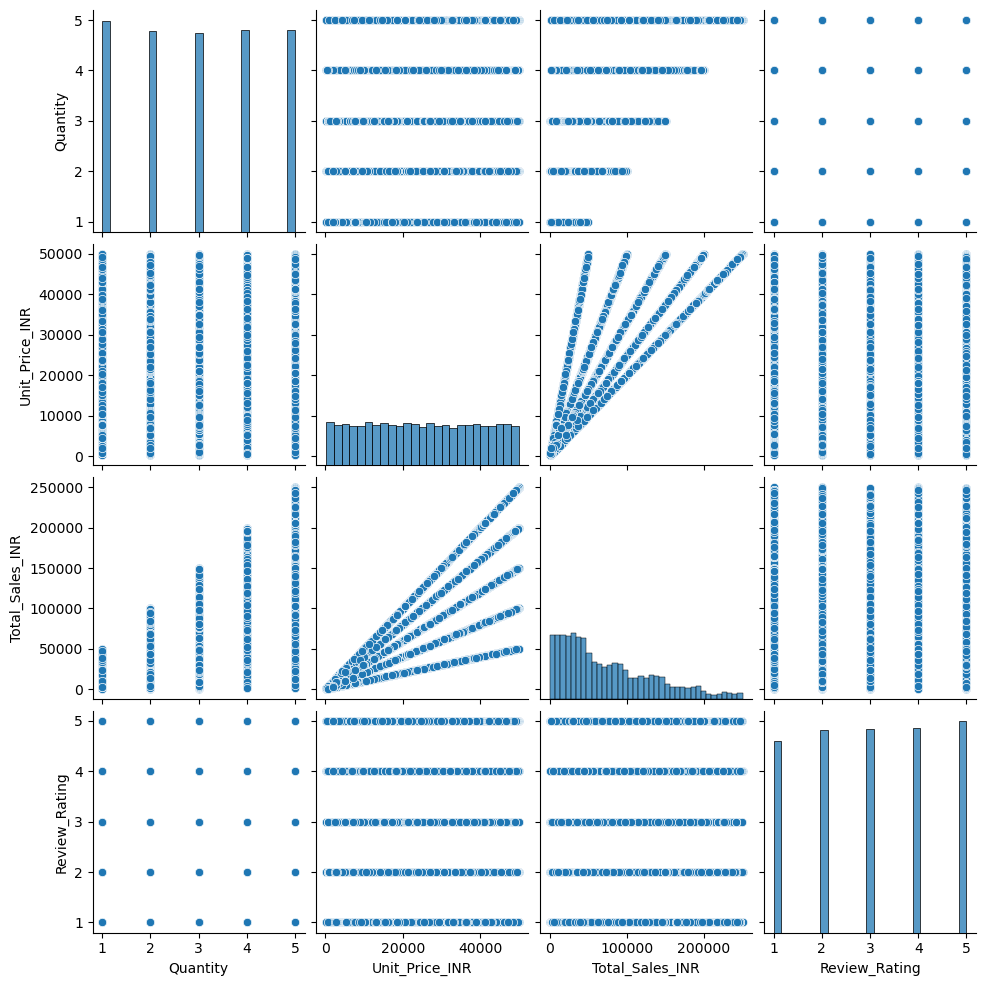

In [8]:
sns.pairplot(df)
plt.show()

### histogram plot

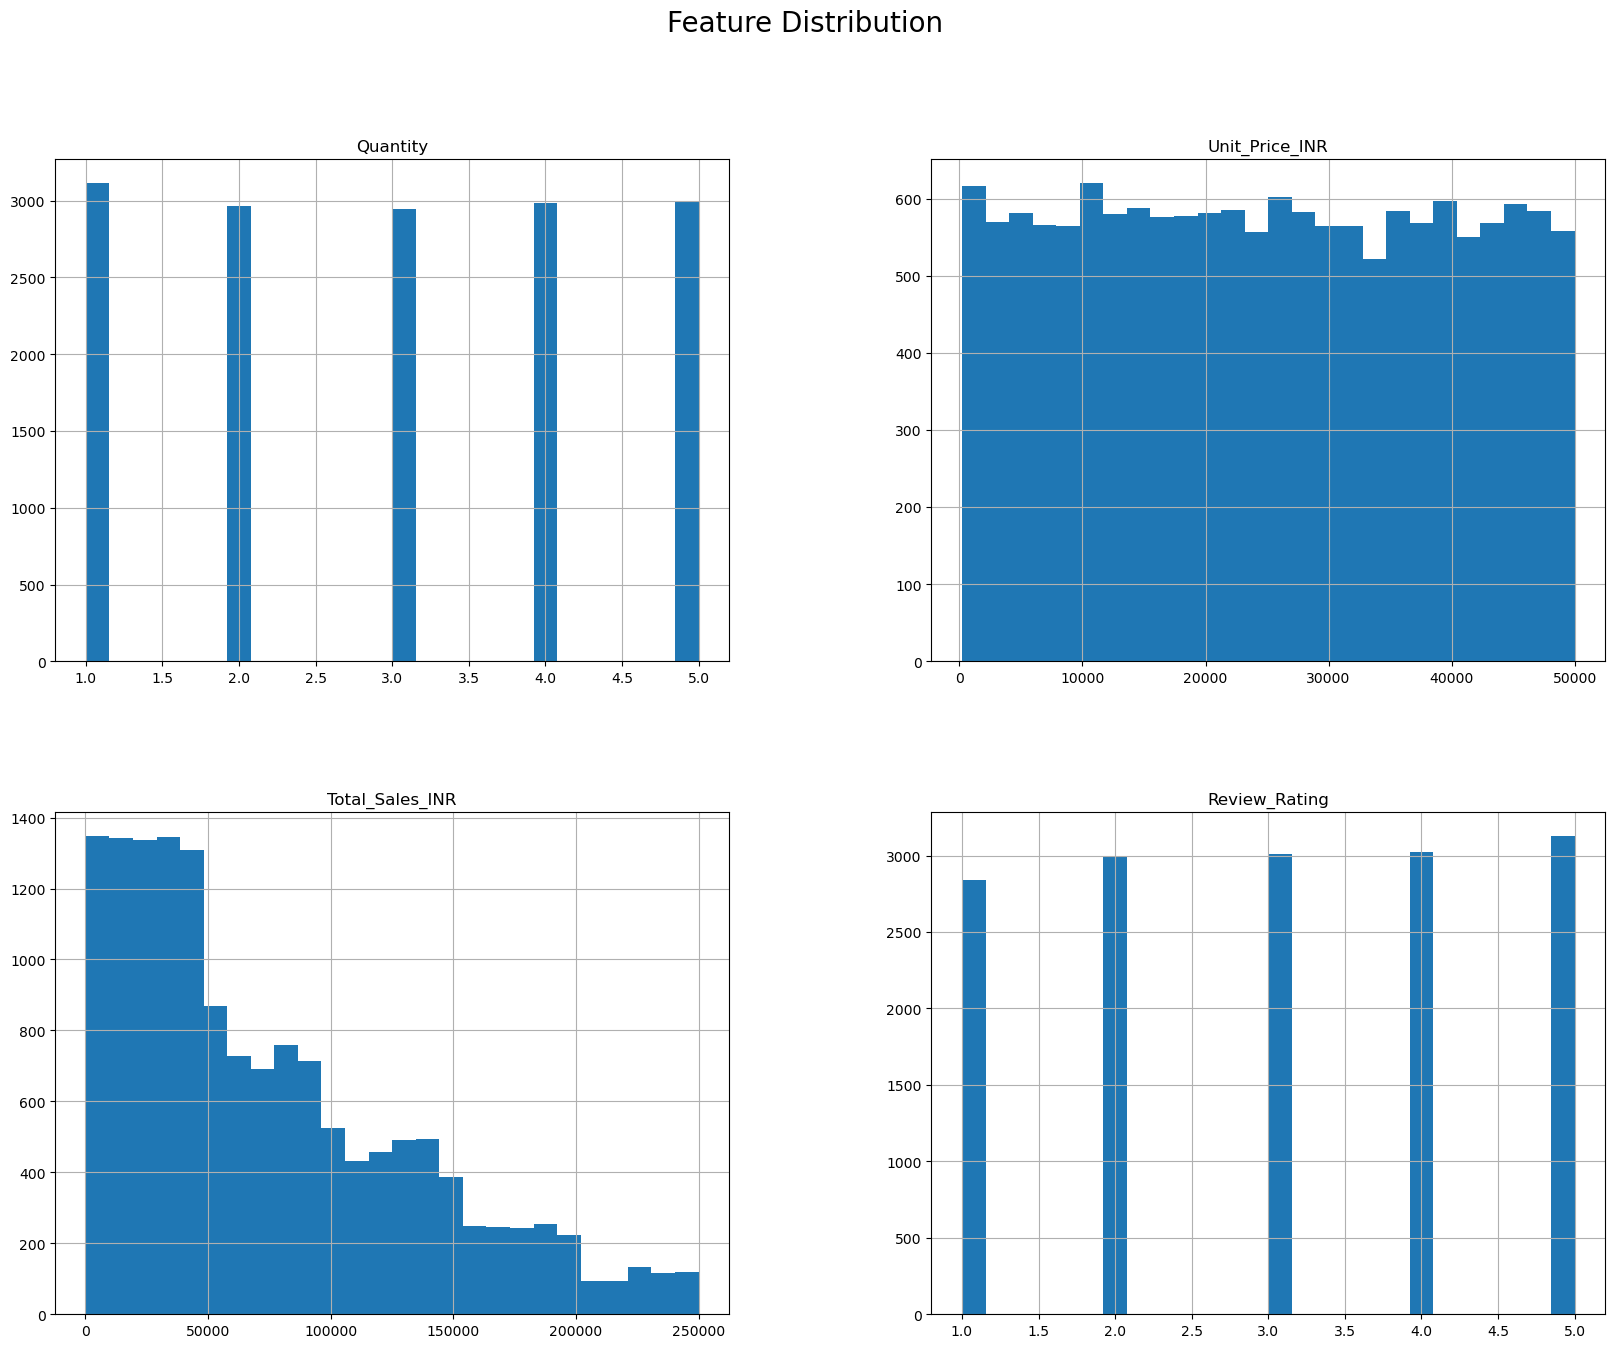

In [10]:
df.hist(figsize=(20, 15), bins=26)
plt.suptitle("Feature Distribution", fontsize=20)
plt.show()

### box plot

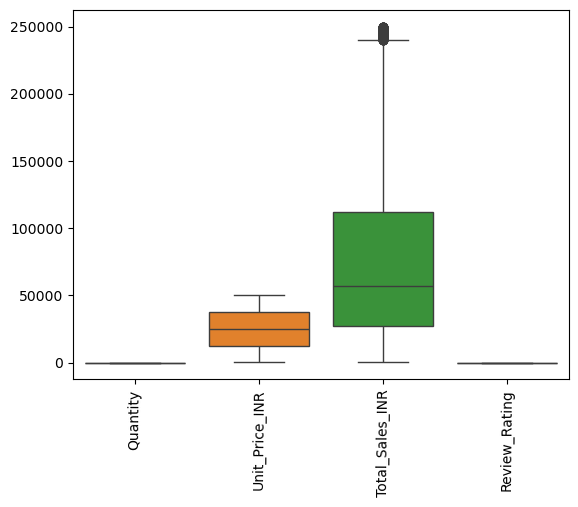

In [11]:
sns.boxplot(df)
plt.xticks(rotation=89.5)
plt.show()

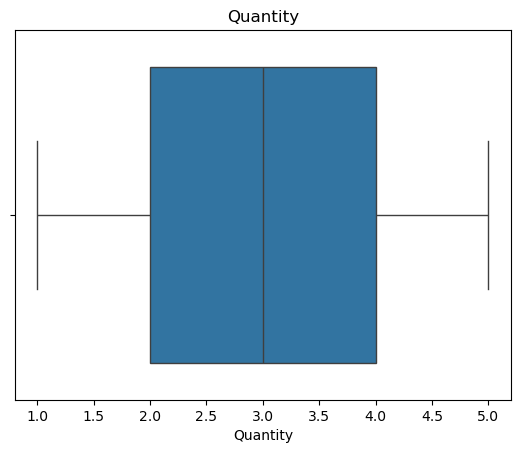

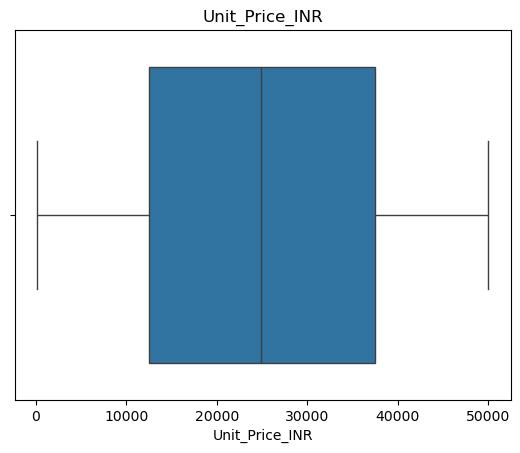

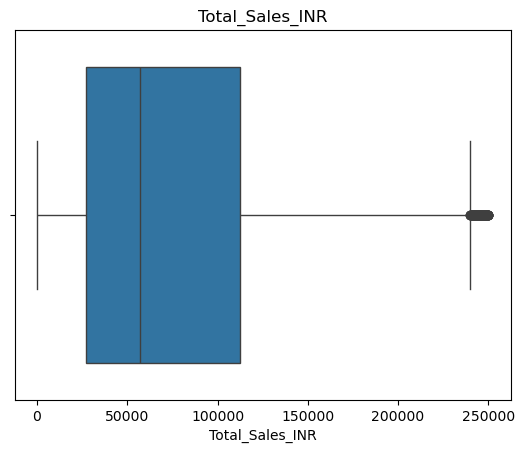

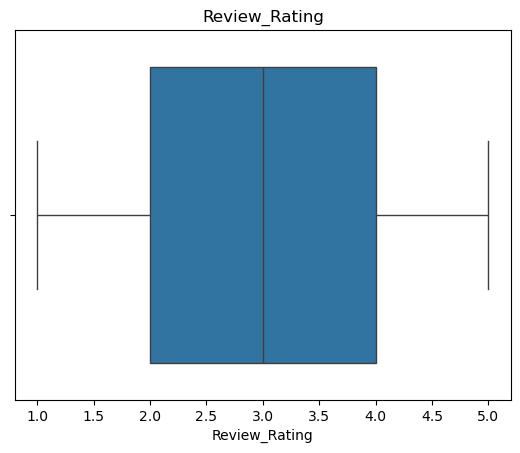

In [12]:
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.title(i)
    plt.show()

In [13]:
Q1 = df['Total_Sales_INR'].quantile(0.25)
Q3 = df['Total_Sales_INR'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [26]:
df_capped = df.copy()
df_capped['Total_Sales_INR'] = df_capped['Total_Sales_INR'].clip(lower=lower_bound, upper=upper_bound)


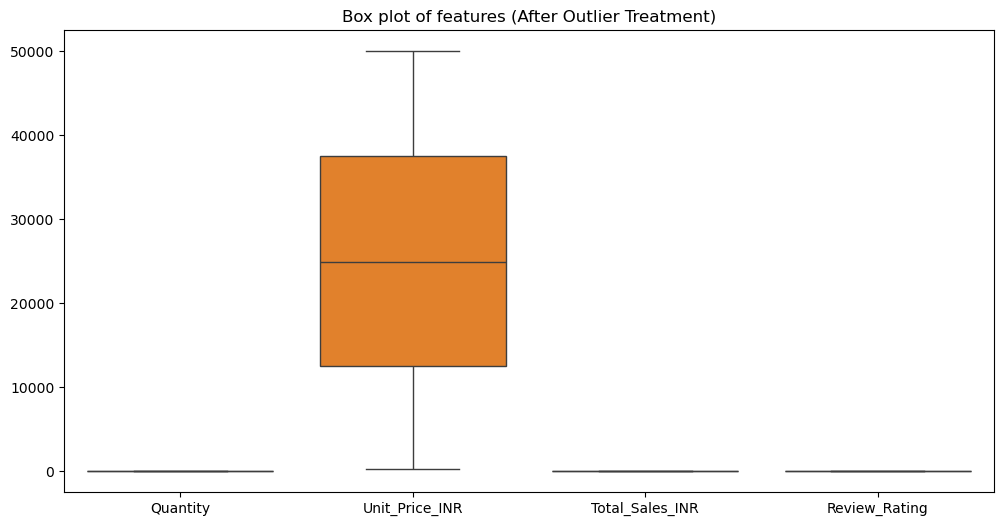

In [27]:
# Plot
plt.figure(figsize=(12,6))
sns.boxplot(data=df_capped)
plt.title('Box plot of features (After Outlier Treatment)')
plt.show()

In [28]:
df_capped.shape

(15000, 14)

In [29]:
for col in df.select_dtypes(include='number'):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"{col}: {count} outliers")


Quantity: 0 outliers
Unit_Price_INR: 0 outliers
Total_Sales_INR: 0 outliers
Review_Rating: 0 outliers


### heat map

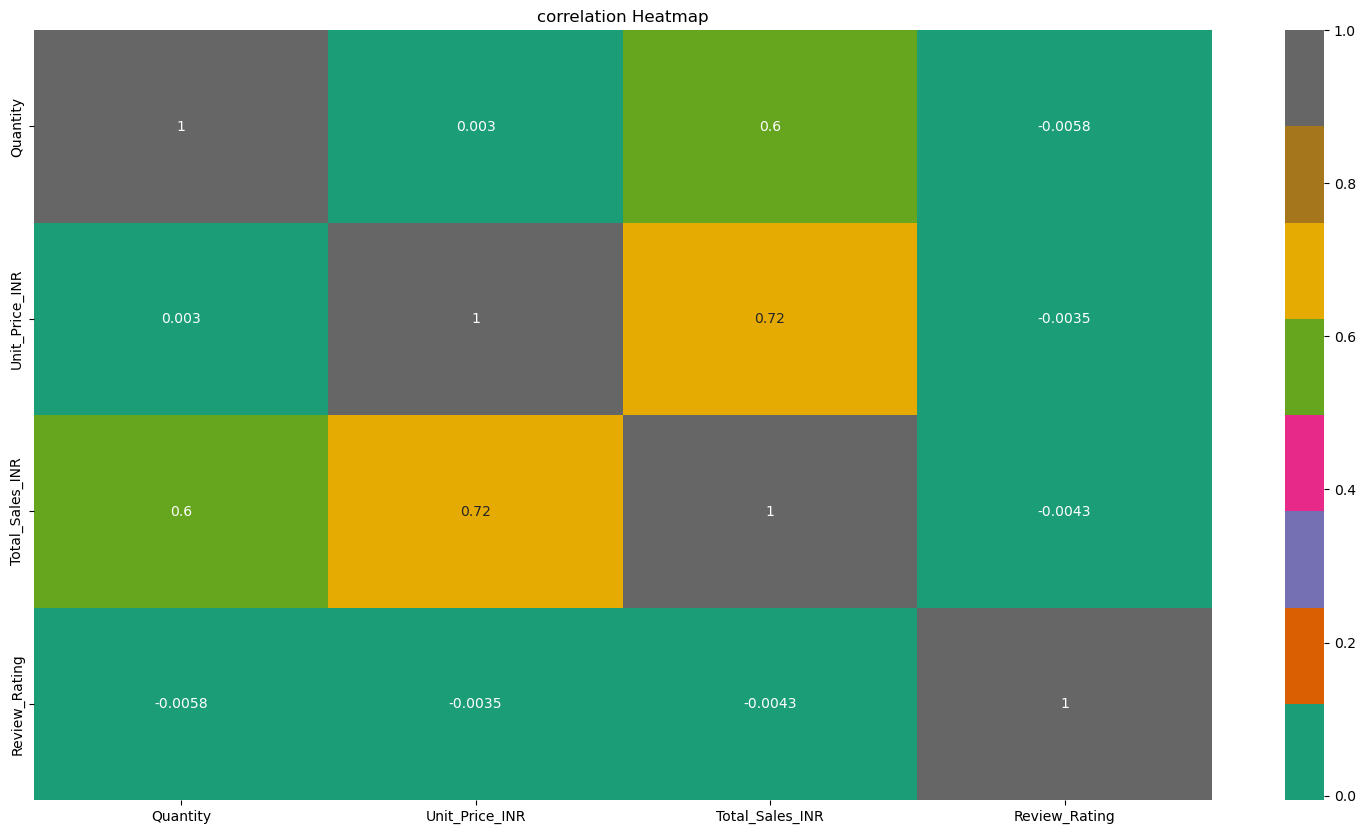

In [30]:
plt.figure(figsize=(19,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Dark2')
plt.title('correlation Heatmap')
plt.show()

### scatter plot

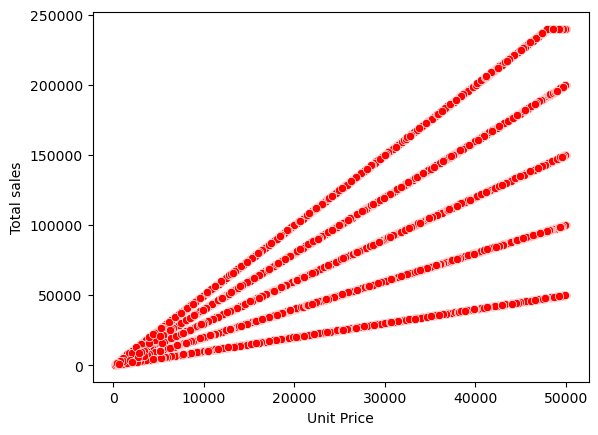

In [31]:
sns.scatterplot(data=df,x='Unit_Price_INR',y='Total_Sales_INR',color='red')
plt.xlabel('Unit Price')
plt.ylabel('Total sales')
plt.show()

## PREPROCESSING

In [10]:
le=LabelEncoder()
df["Order_ID"]=le.fit_transform(df["Order_ID"])

In [11]:
le1=LabelEncoder()
df["Customer_ID"]=le.fit_transform(df["Customer_ID"])

In [12]:
le2=LabelEncoder()
df["Product_Category"]=le.fit_transform(df["Product_Category"])

In [13]:
le3=LabelEncoder()
df["Product_Name"]=le.fit_transform(df["Product_Name"])

In [14]:
le4=LabelEncoder()
df["Payment_Method"]=le.fit_transform(df["Payment_Method"])

In [15]:
le5=LabelEncoder()
df["Delivery_Status"]=le.fit_transform(df["Delivery_Status"])

In [16]:
le6=LabelEncoder()
df["Country"]=le.fit_transform(df["Country"])

In [17]:
le7=LabelEncoder()
df["Review_Text"]=le.fit_transform(df["Review_Text"])

In [18]:
le8=LabelEncoder()
df["State"]=le.fit_transform(df["State"])

In [19]:
le9=LabelEncoder()
df["Date"]=le.fit_transform(df["Date"])

In [20]:
df

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,0,288,1461,4,4,2,25574.41,51148.82,1,2,1,22,21,0
1,1,331,7007,0,7,1,19361.41,19361.41,2,2,5,4,23,0
2,2,313,3891,3,22,3,38476.22,115428.66,0,0,3,5,17,0
3,3,277,3956,3,8,5,38145.72,190728.60,1,0,5,8,2,0
4,4,173,6469,2,15,5,45940.98,229704.90,3,0,5,8,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,135,1485,0,12,4,36421.54,145686.16,3,0,1,10,6,0
14996,14996,342,4164,0,17,4,18158.02,72632.08,2,0,4,18,15,0
14997,14997,312,4643,1,16,1,38864.05,38864.05,3,0,1,22,21,0
14998,14998,245,1426,0,7,3,32658.62,97975.86,0,1,3,13,8,0


In [21]:
x=df.drop('Total_Sales_INR',axis=1)
x

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,0,288,1461,4,4,2,25574.41,1,2,1,22,21,0
1,1,331,7007,0,7,1,19361.41,2,2,5,4,23,0
2,2,313,3891,3,22,3,38476.22,0,0,3,5,17,0
3,3,277,3956,3,8,5,38145.72,1,0,5,8,2,0
4,4,173,6469,2,15,5,45940.98,3,0,5,8,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,135,1485,0,12,4,36421.54,3,0,1,10,6,0
14996,14996,342,4164,0,17,4,18158.02,2,0,4,18,15,0
14997,14997,312,4643,1,16,1,38864.05,3,0,1,22,21,0
14998,14998,245,1426,0,7,3,32658.62,0,1,3,13,8,0


In [22]:
y=df[['Total_Sales_INR']]
y

,Total_Sales_INR
0,51148.82
1,19361.41
2,115428.66
3,190728.60
4,229704.90
...,...
14995,145686.16
14996,72632.08
14997,38864.05
14998,97975.86


### Linear Regression

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=30)

In [30]:
lr=LinearRegression()

In [31]:
lr.fit(x,y)

LinearRegression()

In [32]:
y_predict=lr.predict(x_test)
y_predict

array([[ 18281.99050438],
       [101864.21751539],
       [105947.72468787],
       ...,
       [ 73032.80669832],
       [ 57385.68291089],
       [134244.022088  ]])

In [33]:
lr.score(x_test,y_test)

0.8815934715960088

In [34]:
lr.score(x_train,y_train)

0.8811071470120512

In [35]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print('MAE: ',mean_absolute_error(y_test,y_predict))
print('MSE:',mean_squared_error(y_test,y_predict))
print('r2_score:',r2_score(y_test,y_predict))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_predict)))

MAE:  15353.205778270269
MSE: 428639139.5071903
r2_score: 0.8815934715960088
RMSE: 20703.602090148233


### SCALING

In [52]:
sc=StandardScaler()
x=sc.fit_transform(x)

### LASSO

In [24]:
lasso=Lasso(alpha=10) 
lasso.fit(x_train,y_train)
y_pred_lasso=lasso.predict(x_test)

In [25]:
y_pred_lasso

array([ 18466.9296328 , 101731.02903899, 105232.20620212, ...,
        73409.18525618,  57005.69768922, 134838.77929825])

In [26]:
lasso.score(x_test,y_test)

0.8813064824989868

In [56]:
lasso.score(x_train,y_train)

0.8817223938664734

In [36]:
print('MAE: ',mean_absolute_error(y_test,y_pred_lasso))
print('MSE:',mean_squared_error(y_test,y_pred_lasso))
print('r2_score:',r2_score(y_test,y_pred_lasso))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred_lasso)))

MAE:  15369.881324428326
MSE: 429678058.23281765
r2_score: 0.8813064824989868
RMSE: 20728.67719447668


### RIDGE

In [38]:
ridge=Ridge(alpha=10)
ridge.fit(x_train,y_train)
y_pred_ridge=ridge.predict(x_test)

In [39]:
y_pred_ridge

array([ 18467.72267295, 101753.65968302, 105228.27838199, ...,
        73439.22865309,  56994.25147515, 134838.24753381])

In [40]:
ridge.score(x_test,y_test)

0.8812998325228043

In [41]:
ridge.score(x_train,y_train)

0.8811597293973595

In [42]:
print('MAE: ',mean_absolute_error(y_test,y_pred_ridge))
print('MSE:',mean_squared_error(y_test,y_pred_ridge))
print('r2_score:',r2_score(y_test,y_pred_ridge))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred_ridge)))

MAE:  15372.168211999022
MSE: 429702131.5681903
r2_score: 0.8812998325228043
RMSE: 20729.25786342073


### Decision Tree

In [61]:
dt=DecisionTreeRegressor()

In [62]:
dt.fit(x,y)

DecisionTreeRegressor()

In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=30)

In [64]:
y_pred=dt.predict(x_test)
y_pred

array([ 28988.3 ,  84033.84,  92839.95, ...,  41039.89,  12234.5 ,
       134721.84])

In [65]:
dt.score(x_test,y_test)

1.0

In [66]:
dt.score(x_train,y_train)

1.0

In [67]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print('MAE:',mean_absolute_error(y_test,y_pred))
print('MSE:',mean_squared_error(y_test,y_pred))
print('r2 score:',r2_score(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))

MAE: 5.471520125865936e-12
MSE: 2.8663594935085523e-21
r2 score: 1.0
RMSE: 5.353839270568881e-11


In [68]:
dt.get_depth()

18

### Random Forest

In [69]:
rf=RandomForestRegressor(n_estimators=45,random_state=34)
rf.fit(x_train,y_train)

RandomForestRegressor(n_estimators=45, random_state=34)

In [70]:
y_pred=rf.predict(x_test)
y_pred

array([ 28919.45333333,  84030.41644444,  92881.55111111, ...,
        41043.16422222,  12073.47777778, 134782.12066667])

In [71]:
rf.score(x_test,y_test)

0.9999982484015957

In [72]:
rf.score(x_train,y_train)

0.9999996607600395

In [73]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print('MAE:',mean_absolute_error(y_test,y_pred))
print('MSE:',mean_squared_error(y_test,y_pred))
print('r2 score:',r2_score(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))

MAE: 53.08313569135665
MSE: 6307.653875979286
r2 score: 0.9999982484015957
RMSE: 79.42073958343177


### SVR

In [74]:
linear_model=SVR(kernel='linear',C=1000)
(linear_model.fit(x_train,y_train))
print(linear_model.score(x_test,y_test))
print(linear_model.score(x_train,y_train))

0.8819390231858625
0.8815462003378973


In [75]:
svr_poly = SVR(kernel='poly',degree=4,C=500)
svr_poly.fit(x_train,y_train)
print(svr_poly.score(x_test,y_test))
print(svr_poly.score(x_train,y_train))

-0.018380093919599494
-0.003940761629550149


In [76]:
svr_sig=SVR(kernel='sigmoid',C=700)
svr_sig.fit(x_train,y_train)
svr_sig.score(x_test,y_test)
y_pred=svr_sig.predict(x_test)
print(mean_squared_error(y_test,y_pred))

440959770.4975717


In [77]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print('MAE:',mean_absolute_error(y_test,y_pred))
print('MSE:',mean_squared_error(y_test,y_pred))
print('r2 score:',r2_score(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))

MAE: 15748.930635040495
MSE: 440959770.4975717
r2 score: 0.8775480637396795
RMSE: 20999.042132858624


### KNN

In [48]:
kn=KNeighborsRegressor(n_neighbors=5)
kn.fit(x_train,y_train)

KNeighborsRegressor()

In [49]:
kn.score(x_test,y_test)

0.4227737965739733

In [50]:
kn.score(x_train,y_train)

0.6156023653786986

In [46]:
y_pred=kn.predict(x_test)
y_pred

array([[ 52671.264],
       [126502.324],
       [ 59218.258],
       ...,
       [115422.374],
       [  8243.352],
       [143079.992]])

In [47]:
print('MAE: ',mean_absolute_error(y_test,y_predict))
print('MSE:',mean_squared_error(y_test,y_predict))
print('r2_score:',r2_score(y_test,y_predict))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_predict)))

MAE:  15353.205778270269
MSE: 428639139.5071903
r2_score: 0.8815934715960088
RMSE: 20703.602090148233


## Ensemble Model

In [26]:
adaboost1=AdaBoostRegressor(n_estimators=50,learning_rate=0.3,random_state=1)

In [27]:
adaboost1.fit(x_train,y_train)

AdaBoostRegressor(learning_rate=0.3, random_state=1)

In [28]:
adaboost1.score(x_test,y_test)

0.9483699544966687

In [29]:
adaboost1.score(x_train,y_train)

0.9476148985005005

In [30]:
y_pred=adaboost1.predict(x_test)
y_pred

array([ 35542.41106693,  68813.89718833,  86141.20681709, ...,
        62364.31822254,  16540.00767956, 126374.2783871 ])

In [31]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print('MAE:',mean_absolute_error(y_test,y_pred))
print('MSE:',mean_squared_error(y_test,y_pred))
print('r2 score:',r2_score(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))

MAE: 11633.025473112692
MSE: 186904037.9408591
r2 score: 0.9483699544966687
RMSE: 13671.285160542118


### XGBoost

In [86]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [34]:
from xgboost import XGBRegressor

In [35]:
xg=XGBRegressor()
xg.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
xg.score(x_test,y_test)

0.9999426603317261

In [37]:
xg.score(x_train,y_train)

0.9999764561653137

In [38]:
y_pred=xg.predict(x_test)
y_pred

array([ 28814.691,  83277.11 ,  92902.44 , ...,  40695.96 ,  11385.128,
       134556.5  ], dtype=float32)

In [39]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print('MAE:',mean_absolute_error(y_test,y_pred))
print('MSE:',mean_squared_error(y_test,y_pred))
print('r2 score:',r2_score(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))

MAE: 327.9308776855469
MSE: 207588.515625
r2 score: 0.9999426603317261
RMSE: 455.6188271186782


### Gradient Boost

In [52]:
gbc=GradientBoostingRegressor(n_estimators=100,random_state=12)
gbc.fit(x_train,y_train)

GradientBoostingRegressor(random_state=12)

In [53]:
gbc.score(x_test,y_test)

0.9992781892663144

In [54]:
gbc.score(x_train,y_train)

0.9992897464738606

In [55]:
y_pred=gbc.predict(x_test)
y_pred

array([ 27291.04739118,  84690.44037494,  92556.47174785, ...,
        41161.99119827,  12381.05039825, 133957.82371958])

In [56]:
print('MAE: ',mean_absolute_error(y_test,y_predict))
print('MSE:',mean_squared_error(y_test,y_predict))
print('r2_score:',r2_score(y_test,y_predict))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_predict)))

MAE:  15353.205778270269
MSE: 428639139.5071903
r2_score: 0.8815934715960088
RMSE: 20703.602090148233


### Hyperparameter Tuning

In [94]:
lr_params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr_grid = GridSearchCV(LinearRegression(), lr_params, cv=5)
lr_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]})

In [95]:
rf_params={'n_estimators':[10,50,100],
           'max_depth':[2,4,6, None]}
rf_grid=GridSearchCV(RandomForestRegressor(random_state=42),rf_params,cv=5)
rf_grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [2, 4, 6, None],
                         'n_estimators': [10, 50, 100]})

In [96]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

dt_params = {
    'max_depth': [2, 4, 6, None],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [2, 4, 6, None]},
             scoring='r2')

In [97]:
svr_params={'C':[0.1,1,10],
            'kernel':['linear','rbf'],
            'gamma':['scale','auto']}  # 'scale': default values based on features,'auto':uses
svr_grid = GridSearchCV(SVR(), svr_params, cv=5, n_jobs=-1)
svr_grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']})

In [98]:
kn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'manhattan']
}

kn_grid = GridSearchCV(KNeighborsRegressor(), kn_params, cv=5)
kn_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'metric': ['minkowski', 'euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [99]:
ab_params = {
    'n_estimators': [10, 50, 100, 200],
    'estimator__max_depth': [2, 4, 6, None]  # DecisionTree depth
}

ab_grid = GridSearchCV(
    AdaBoostRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        random_state=42
    ),
    ab_params,
    cv=5
)

ab_grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=42),
                                         random_state=42),
             param_grid={'estimator__max_depth': [2, 4, 6, None],
                         'n_estimators': [10, 50, 100, 200]})

In [100]:
xg_params = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [2, 4, 6, 8]  # no None
}

xg_grid = GridSearchCV(
    XGBRegressor(random_state=42, eval_metric='rmese'),
    xg_params,
    cv=5
)

xg_grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False,
                                    eval_metric='rmse', feature_types=None,
                                    feature_weights=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'max_depth': [2, 4, 6, 8],
                         'n_estimators': [10, 50, 100, 200]})

In [101]:
gb_params = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [2, 3, 4, 5, 6]   # remove None
}
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5
)
gb_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             param_grid={'max_depth': [2, 3, 4, 5, 6],
                         'n_estimators': [10, 50, 100, 200]})

In [102]:
from sklearn.metrics import r2_score

models = {
    "Linear Regression":lr_grid,
    "Random Forest": rf_grid,
    "SVR": svr_grid,
    "Decision Tree": dt_grid,
    "KNNeighbors": kn_grid,
    "XGBoost": xg_grid
}

for name, grid in models.items():
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)

    
    r2 = r2_score(y_test, y_pred)

    print(f"{name}:")
    print(f"best param: {grid.best_params_}")
    print(f"R2 Score: {r2:.4f}\n")

Linear Regression:
best param: {'fit_intercept': True, 'positive': True}
R2 Score: 0.8822

Random Forest:
best param: {'max_depth': None, 'n_estimators': 100}
R2 Score: 1.0000

SVR:
best param: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
R2 Score: 0.7908

Decision Tree:
best param: {'criterion': 'friedman_mse', 'max_depth': None}
R2 Score: 1.0000

KNNeighbors:
best param: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}
R2 Score: 0.8901

XGBoost:
best param: {'max_depth': 8, 'n_estimators': 100}
R2 Score: 1.0000



In [103]:
best_xg_model = xg_grid.best_estimator_
y_pred = best_xg_model.predict(x_test)

In [104]:
print(best_xg_model )

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


In [105]:
import joblib
joblib.dump(rf,"project.pkl")

['project.pkl']

In [106]:
joblib.dump(sc,"scaler.pkl")

['scaler.pkl']

In [107]:
joblib.dump(le,"le.pkl")

['le.pkl']

In [108]:
joblib.dump(le1,"le1.pkl")

['le1.pkl']

In [109]:
joblib.dump(le2,"le2.pkl")

['le2.pkl']

In [110]:
joblib.dump(le3,"le3.pkl")

['le3.pkl']

In [111]:
joblib.dump(le4,"le4.pkl")

['le4.pkl']

In [112]:
joblib.dump(le5,"le5.pkl")

['le5.pkl']

In [113]:
joblib.dump(le6,"le6.pkl")

['le6.pkl']

In [114]:
joblib.dump(le7,"le7.pkl")

['le7.pkl']

In [115]:
joblib.dump(le8,"le8.pkl")

['le8.pkl']

In [116]:
joblib.dump(le9,"le9.pkl")

['le9.pkl']